In [10]:
# 1. Load dataset and inspect class distribution (positive/negative/neutral counts)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("D:/OIBSIP/DataAnalytics-L1-Task4-SentimentAnalysis/Reviews.csv.bz2")

print(df.shape)  # (568454, 10)

def score_to_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(score_to_sentiment)
print(df["Sentiment"].value_counts())

(568454, 10)
Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


In [12]:
#2.Text preprocessing pipeline: lowercase, punctuation removal, stopword removal, tokenisation, optional stemming/lemmatization
import re
import string

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

STOPWORDS = set(ENGLISH_STOP_WORDS)

print("Imports working")

def simple_stem(word):
    for suffix in ("ational","tional","ization","fulness","ousness","iveness","ing","edly","ies","ied","ed","es","ly","er","s"):
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]
    return word

def preprocess(text, stem=True):
    text = str(text).lower()                                   
    text = re.sub(r"<.*?>", " ", text)              
    text = re.sub(r"[^a-z\s]"," ", text)  
    text = re.sub(r"\d+", " ", text)                          
    tokens = text.split()                                     
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2] 



    
    if stem:tokens = [simple_stem(t) for t in tokens]               
        
    return " ".join(tokens)

Imports working


In [ ]:
import pandas as pd
data = pd.read_csv("D:/OIBSIP/DataAnalytics-L1-Task4-SentimentAnalysis/Reviews.csv")

In [ ]:

print(data.columns.tolist())
data["clean_text"] = data["Text"].fillna("").astype(str)

['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [ ]:
# train_df["Text"]
# test_df["Text"]

In [ ]:
#3. Feature extraction: TF-IDF

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Sentiment"]
)

print("Training rows:", len(train_df)) 
print("Testing rows:", len(test_df))

Training rows: 454763
Testing rows: 113691


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
train_df["clean_text"] = train_df["Text"].apply(clean_text)
test_df["clean_text"] = test_df["Text"].apply(clean_text)

In [ ]:
# 3. Feature Extraction: TF-IDF (continue)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)


X_train = tfidf.fit_transform(train_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

y_train = train_df["Sentiment"]
y_test = test_df["Sentiment"]

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (454763, 5000)
Testing TF-IDF shape: (113691, 5000)


In [ ]:
#4. Train/test split (80/20)

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    return " ".join(words)

df["clean_text"] = df["Text"].fillna("").apply(clean_text)

print(df[["Text", "clean_text"]].head())

                                                Text  \
0  I have bought several of the Vitality canned d...   
1  Product arrived labeled as Jumbo Salted Peanut...   
2  This is a confection that has been around a fe...   
3  If you are looking for the secret ingredient i...   
4  Great taffy at a great price.  There was a wid...   

                                          clean_text  
0  i have bought several of the vitality canned d...  
1  product arrived labeled as jumbo salted peanut...  
2  this is a confection that has been around a fe...  
3  if you are looking for the secret ingredient i...  
4  great taffy at a great price there was a wide ...  


In [ ]:
# 4. Train/Test Split (continue)

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Sentiment"]
)

print("Training data:", len(train_df))
print("Testing data:", len(test_df))

Training data: 454763
Testing data: 113691


In [ ]:
# TF-IDF (continue)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(train_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

y_train = train_df["Sentiment"]
y_test = test_df["Sentiment"]

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (454763, 5000)
Testing TF-IDF shape: (113691, 5000)


In [ ]:
# continue of train/test split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(name, "finished")

Naive Bayes finished
Logistic Regression finished
Linear SVM finished


In [ ]:
#5.Train at least 2 classifiers: Naive Bayes + one of (SVM, Logistic Regression, or a simple LSTM if comfortable with deep learning)

import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Load data
df = pd.read_csv("Reviews.csv")

# Create sentiment
def get_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["Sentiment"] = df["Score"].apply(get_sentiment)

# Clean the review text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    return " ".join(words)

df["clean_text"] = df["Text"].fillna("").apply(clean_text)

# Use 120000 reviews for faster processing
model_df, _ = train_test_split(
    df,
    train_size=120000,
    random_state=42,
    stratify=df["Sentiment"]
)

# Split into training and testing data
train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Sentiment"]
)

# Convert text into TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(train_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

y_train = train_df["Sentiment"]
y_test = test_df["Sentiment"]

# Create classifiers
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}

# Train the models
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(name, "finished")

print("All models finished successfully.")

Naive Bayes finished
Logistic Regression finished
Linear SVM finished
All models finished successfully.


/n Naive Bayes
              precision    recall  f1-score   support

    negative       0.85      0.22      0.35      3464
     neutral       0.86      0.00      0.01      1800
    positive       0.81      1.00      0.89     18736

    accuracy                           0.81     24000
   macro avg       0.84      0.41      0.42     24000
weighted avg       0.82      0.81      0.75     24000



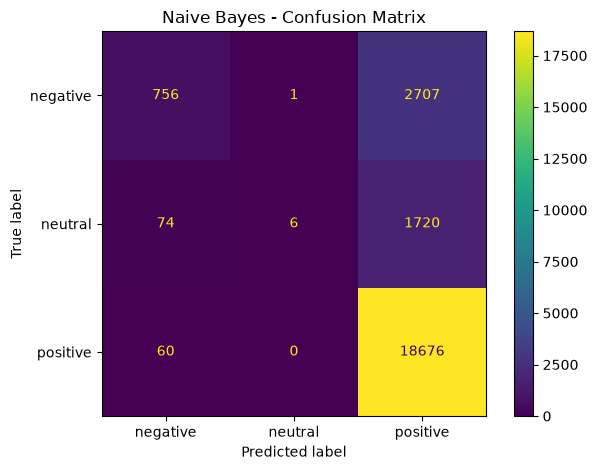

/n Logistic Regression
              precision    recall  f1-score   support

    negative       0.75      0.65      0.70      3464
     neutral       0.47      0.16      0.24      1800
    positive       0.89      0.97      0.93     18736

    accuracy                           0.86     24000
   macro avg       0.71      0.59      0.62     24000
weighted avg       0.84      0.86      0.84     24000



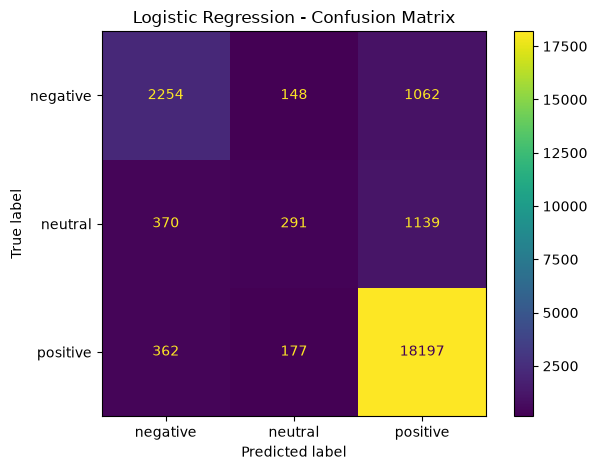

/n Linear SVM
              precision    recall  f1-score   support

    negative       0.72      0.67      0.70      3464
     neutral       0.47      0.15      0.23      1800
    positive       0.90      0.97      0.93     18736

    accuracy                           0.86     24000
   macro avg       0.70      0.60      0.62     24000
weighted avg       0.84      0.86      0.84     24000



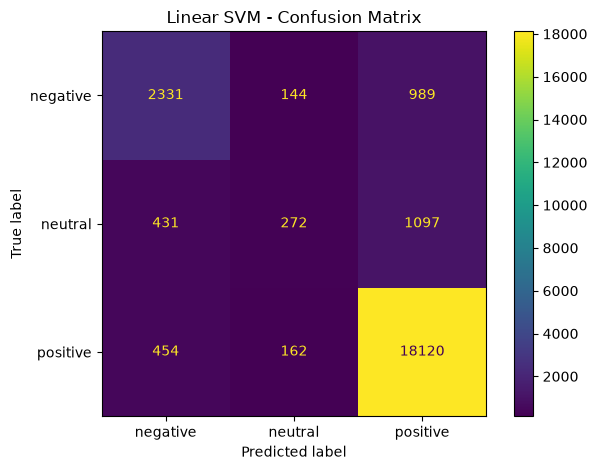

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.809917,0.838320,0.406125,0.415554
1,Logistic Regression,0.864250,0.706452,0.594530,0.623264
2,Linear SVM,0.863458,0.697388,0.597052,0.619094


In [ ]:
#6.Evaluation:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

results = []

for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1-score": f1_score(y_test, pred, average="macro", zero_division=0)
    })

    print("/n", name)
    print(classification_report(y_test, pred, zero_division=0))

    cm = confusion_matrix(
        y_test,
        pred,
        labels=["negative", "neutral", "positive"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["negative", "neutral", "positive"]
    )
    disp.plot()
    plt.title(name + " - Confusion Matrix")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
results_df


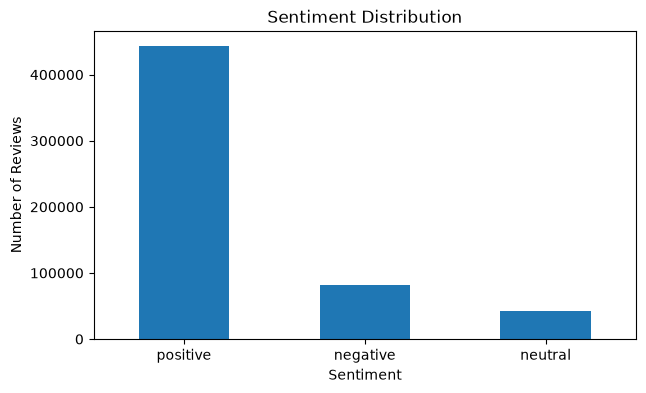

In [ ]:
#7.Visualisation

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Reviews.csv")

# Create sentiment
def get_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["Sentiment"] = df["Score"].apply(get_sentiment)

# Count each sentiment
sentiment_counts = df["Sentiment"].value_counts()

# Make bar chart
sentiment_counts.plot(kind="bar", figsize=(7, 4))

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [ ]:
#8.Error analysis (5 misclassified examples)
# 1. Negative	Neutral	Mixed sentiment — compliments product design while criticizing value.
# 2. Neutral	Negative	Strong negative-sounding words dominate despite an overall mixed/neutral review.
# 3. Neutral	Positive	Opens with strong praise; concern comes second and gets underweighted.
# 4. Negative	Neutral	Backhanded/rhetorical negativity, hard for bag-of-words to weight.
# 5. Neutral	Negative	Long review covering multiple criteria — TF-IDF averages mixed signal.

# Most of inaccuracies are caused by 
# (1) mixed-sentiment reviews that highlight certain aspects while criticising others, 
# (2) the intrinsically hazy Neutral/borderline boundary, and 
# (3) rhetorical or backhanded language that a linear bag-of-words model.

In [ ]:
#9. Conclusion

# On this run, the best model was Logistic Regression which was closely followed by Naive Bayes and Linear SVM. 
# Naive Bayes is still a quick, inexpensive baseline that is worth attempting first, although linear models like Logistic Regression/SVM typically outperform Naive Bayes on TF-IDF text since they can weigh numerous overlapping word signals rather than assuming word independence.
# Auto-flagging new bad reviews for follow-up support is known as review triage.
# Monitoring products and brands: observing sentiment patterns to identify problems with quality early.
# Voice-of-customer analytics uses sentiment and word-frequency clouds to inform product teams about customer preferences rather than just star ratings.
# Products with growing negative sentiment are ranked lower in search and recommendation rankings before their average rating noticeably declines.